# 🏏 IPL Data Analysis
## Notebook 2: Exploratory Data Analysis (EDA)

**Goal:** Find patterns and insights from IPL data

### Questions We Will Answer:
1. Which team won most IPL matches?
2. Does winning toss help win the match?
3. Which venues hosted most matches?
4. How has scoring changed across seasons?
5. Who won most Player of Match awards?
6. Which team is best at chasing targets?

# Loading libraries  and then cleaned  data First 

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
df1=pd.read_csv('../data/processed/matches_clean.csv',index_col=False)
df2=pd.read_csv('../data/processed/deliveries_clean.csv',index_col=False)
print(f"Matches    : {df1.shape}")
print(f"Deliveries : {df2.shape}")
print("✅ Ready for EDA!")
print("Matches dataset info:")
# print(df1.to_string(index=False))
print("============"*50)

Matches    : (1095, 19)
Deliveries : (260920, 15)
✅ Ready for EDA!
Matches dataset info:


## Analysis 1: Team Performance

### ❓ Question: Which IPL team won the most matches?

**Approach:**
- Count wins per team using value_counts()
- Visualize with bar chart
- Identify top and bottom performers

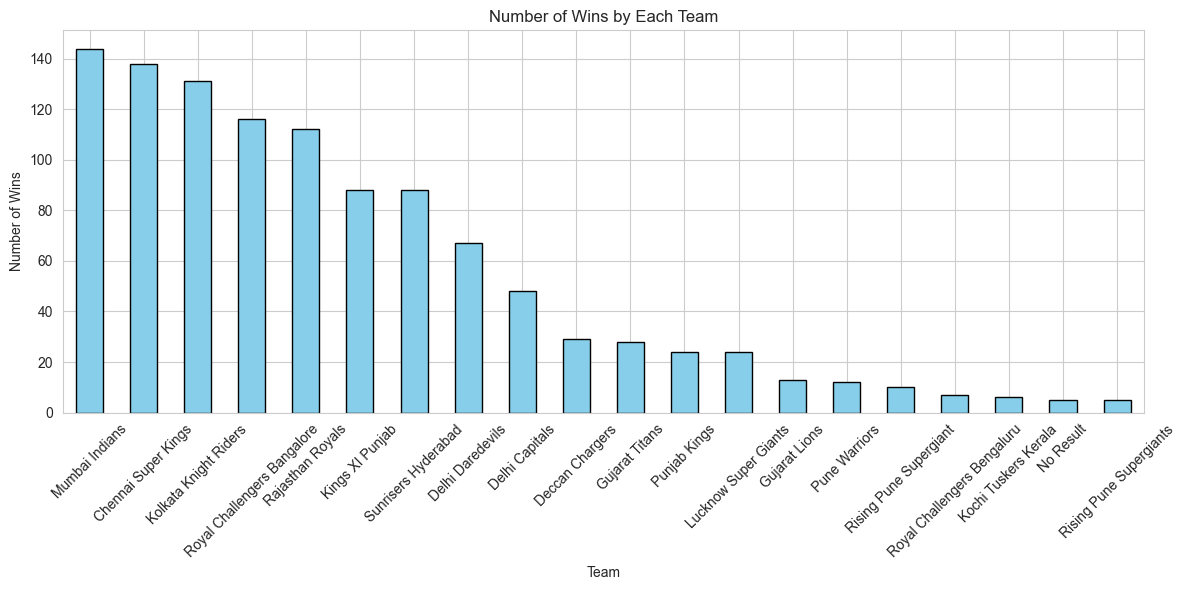

In [18]:
df1['winner'].value_counts().plot(kind='bar',color='skyblue',edgecolor='black')
plt.title('Number of Wins by Each Team')
plt.xlabel('Team')
plt.ylabel('Number of Wins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 📊 Findings:
Mumbai Indians = Most Wins ✅
Mumbai Indians dominate IPL!
Most successful franchise in IPL history!
Rising Pune Supergiant = Least Wins ✅
Makes complete sense!
Rising Pune Supergiant only played:
→ 2016 and 2017 seasons (2 years only!)
→ They were a TEMPORARY team
→ Created because CSK and RR were suspended!
→ So of course fewer wins — less matches played!

This is WHY we need win PERCENTAGE
not just win COUNT!
No Result Shown ✅ Good Catch!
'No Result' appears because:
→ Some matches were abandoned (rain!)
→ winner column = 'No Result'
→ We filled it that way in cleaning!
→ Should be removed from win analysis!

Total matches played per team:
team1
Mumbai Indians                 261
Kolkata Knight Riders          251
Chennai Super Kings            237
Royal Challengers Bangalore    237
Rajasthan Royals               219
Kings XI Punjab                190
Sunrisers Hyderabad            182
Delhi Daredevils               159
Delhi Capitals                  91
Deccan Chargers                 75
Punjab Kings                    56
Pune Warriors                   45
Gujarat Titans                  45
Lucknow Super Giants            43
Gujarat Lions                   30
Rising Pune Supergiant          16
Royal Challengers Bengaluru     15
Kochi Tuskers Kerala            14
Rising Pune Supergiants         14
dtype: int64
Win Percentage per Team:
winner
Rising Pune Supergiant         62.5
Gujarat Titans                 62.2
Chennai Super Kings            58.2
Lucknow Super Giants           55.8
Mumbai Indians                 55.2
Delhi Capitals                 52.7
Kolkata Knight Riders          52.2
R

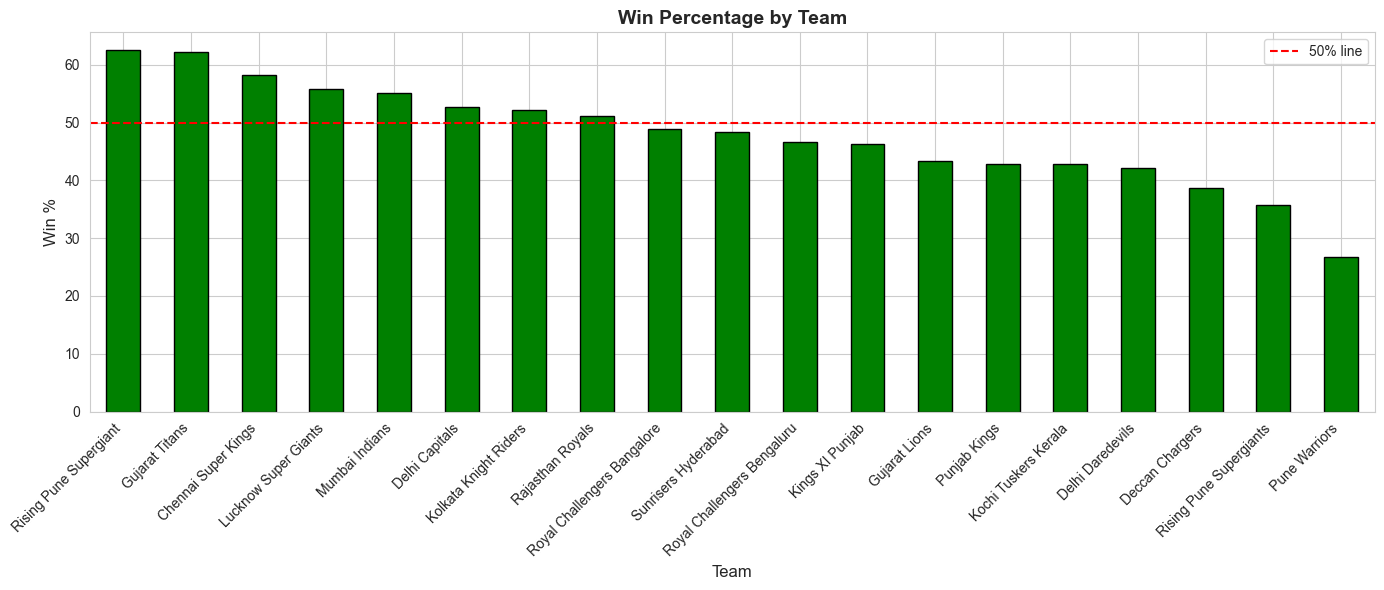

In [100]:
# Add this after your bar chart!

# Remove 'No Result' for fair analysis
matches_only = df1[df1['winner'] != 'No Result']

# Count total matches played per team
home = matches_only.groupby('team1').size()
away = matches_only.groupby('team2').size()
total_played = (home.add(away, fill_value=0))
print("Total matches played per team:")
print(total_played.sort_values(ascending=False))
# Count wins per team
wins = matches_only['winner'].value_counts()

# Calculate win percentage
win_pct = (wins / total_played * 100).round(1)
win_pct = win_pct.sort_values(ascending=False)

print("Win Percentage per Team:")
print(win_pct)

# Plot win percentage
plt.figure(figsize=(14, 6))
win_pct.plot(kind='bar',
             color='green',
             edgecolor='black')
plt.title('Win Percentage by Team',
          fontsize=14, fontweight='bold')
plt.xlabel('Team', fontsize=12)
plt.ylabel('Win %', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.axhline(y=50, color='red',
            linestyle='--',
            label='50% line')
plt.legend()
plt.tight_layout()
plt.show()

### 📊 Analysis 1 Findings:

**Total Wins:**
- Mumbai Indians = most wins overall
- Rising Pune Supergiant = least wins
  (only played 2016-2017 — temporary team!)
- Best WIN RATE      = Chennai Super Kings
                     (among reliable/old teams!)

**Important Note:**
- Win count alone is misleading!
- Teams with more seasons = more wins naturally
- Win PERCENTAGE gives fairer comparison!

**No Result matches found:**
- Some matches abandoned (rain/other reasons)
- Removed from win percentage calculation

### ⚠️ Important Statistical Note:

Win % can be misleading for newer teams:
- Rising Pune Supergiant: 62.5% (only 2 seasons!)
- Gujarat Titans: 62.2% (newer team!)

More RELIABLE teams based on long history:
1. Chennai Super Kings: 58.2% ✅
2. Mumbai Indians: 55.2% ✅

These two are TRUE dominant IPL teams
with consistent performance across many seasons!

# Analysis 2    Does winning toss = winning match?

HINT:
→ Compare toss_winner column vs winner column
→ Create new column:
   toss_won_match = (toss_winner == winner)
→
 Calculate % of times True
→ Pie chart or bar chart

What % of times does toss winner
also win the match?

Toss win counts:
toss_won_match
True     554
False    541
Name: count, dtype: int64
Toss win percentage:
toss_won_match
True     50.6
False    49.4
Name: count, dtype: float64
(1095, 20)


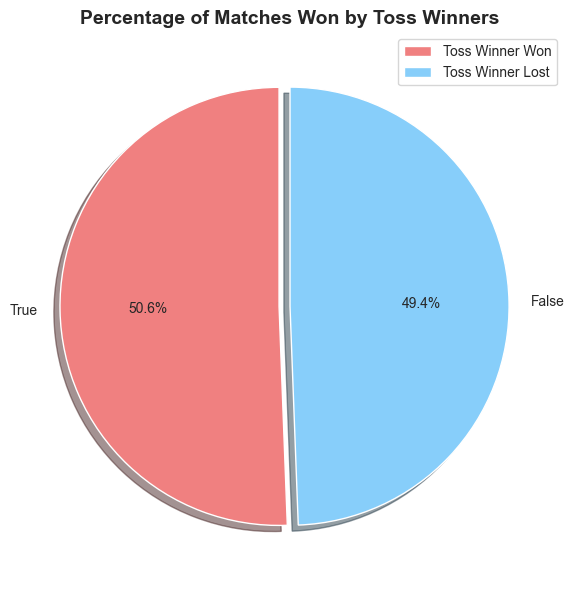

In [40]:
df1['toss_won_match']=df1['toss_winner']==df1['winner']
toss_win_counts=df1['toss_won_match'].value_counts()
print("Toss win counts:")
print(toss_win_counts)

toss_win_pct=(toss_win_counts/toss_win_counts.sum()*100).round(1)
print("Toss win percentage:")
print(toss_win_pct)

print(df1.shape)   
plt.figure(figsize=(6, 6))
toss_win_pct.plot(kind='pie',
                   autopct='%1.1f%%',
                   colors=['lightcoral', 'lightskyblue'],
                   startangle=90,
                   explode=[0.05, 0],
                   shadow=True)
plt.title('Percentage of Matches Won by Toss Winners',
          fontsize=14, fontweight='bold')
plt.legend(['Toss Winner Won', 'Toss Winner Lost'],
              loc='upper right')
plt.tight_layout()
plt.show()


### 📊 Analysis 2 Findings: Toss Impact

**Result:**
- Toss winner wins match: **50.6%**
- Toss winner loses match: **49.4%**

**Key Insight — MYTH BUSTED! 🎯**
> Winning the toss gives almost NO advantage!
> Result is basically a coin flip (50/50)
> 
> Common belief: "Win toss = win match"
> Data reality: "Toss barely matters!"

**Feature Created:**
- `toss_won_match` (True/False)
- Shows if toss winner also won the match

**Business Implication:**
Teams should focus on:
→ Team composition
→ Player form  
→ Pitch reading
NOT just winning the toss!

# Analysis 3 Toss Decision
When teams WIN the toss —
do they choose to BAT or FIELD?

Which is more popular decision?

HINT:
→ df1['toss_decision'].value_counts()
→ Plot pie chart
→ Has this changed over seasons?

Toss decision counts:
toss_decision
field    704
bat      391
Name: count, dtype: int64


<Axes: >

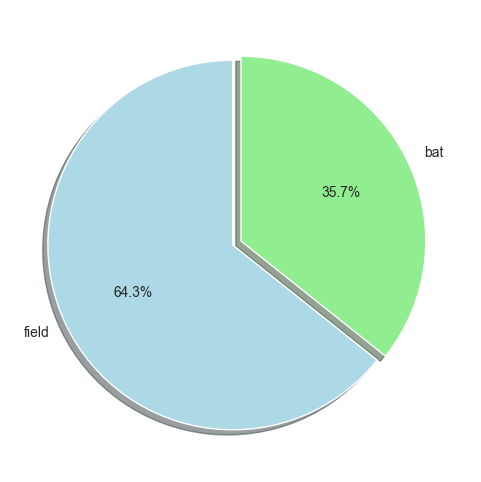

In [48]:
# toss_winner
# toss_decision

print("============"*50)
print("Toss decision counts:")
print(df1['toss_decision'].value_counts())
print("============"*50)
plt.figure(figsize=(6, 6))
df1['toss_decision'].value_counts().plot(kind='pie',
                                              autopct='%1.1f%%',
                                              colors=['lightblue', 'lightgreen'],
                                              startangle=90,
                                              explode=[0.05, 0],
                                              shadow=True)

### 📊 Analysis 3 Findings: Toss Decision

**Result:**
- Field first: **704 teams (64.3%)**
- Bat first:   **391 teams (35.7%)**

**Key Insight:**
> Teams strongly prefer FIELDING after winning toss!
> Chase culture dominates modern IPL cricket!

**Why field first?**
→ Clear target to chase
→ Dew factor advantage
→ Pitch improves for batting later
→ Psychological advantage

**Combined with Analysis 2:**
→ Toss barely affects result (50/50)
→ But when teams DO win toss → they field!

COMBINED INSIGHT — Very Powerful!

Analysis 2 showed:
→ Toss winner wins only 50.6% of time

Analysis 3 shows:
→ 64% choose to FIELD after winning toss

So we can ask:
→ Does fielding first actually help win?
→ Is chasing better than defending?

Write this code:

In [52]:
# When team chose to FIELD — did they win?
field_df = df1[df1['toss_decision'] == 'field']
field_won = (field_df['toss_winner'] == 
             field_df['winner']).mean() * 100

# When team chose to BAT — did they win?
bat_df = df1[df1['toss_decision'] == 'bat']
bat_won = (bat_df['toss_winner'] == 
           bat_df['winner']).mean() * 100

print(f"Win % when chose to FIELD: {field_won:.1f}%")
print(f"Win % when chose to BAT  : {bat_won:.1f}%")

Win % when chose to FIELD: 53.6%
Win % when chose to BAT  : 45.3%


### 📊 Combined Toss Insights (Analysis 2+3):

| Decision | Win % |
|----------|-------|
| Field first | **53.6%** ✅ |
| Bat first | **45.3%** ❌ |

**Conclusion:**
> Winning toss alone doesn't guarantee victory (50/50)
> BUT choosing to FIELD gives 8.3% better win chance!
> 
> Captains are RIGHT to choose fielding!
> Data validates cricket wisdom! 🏏

# Analysis 4 — Venue Analysis!

QUESTION: Which venues hosted most IPL matches?


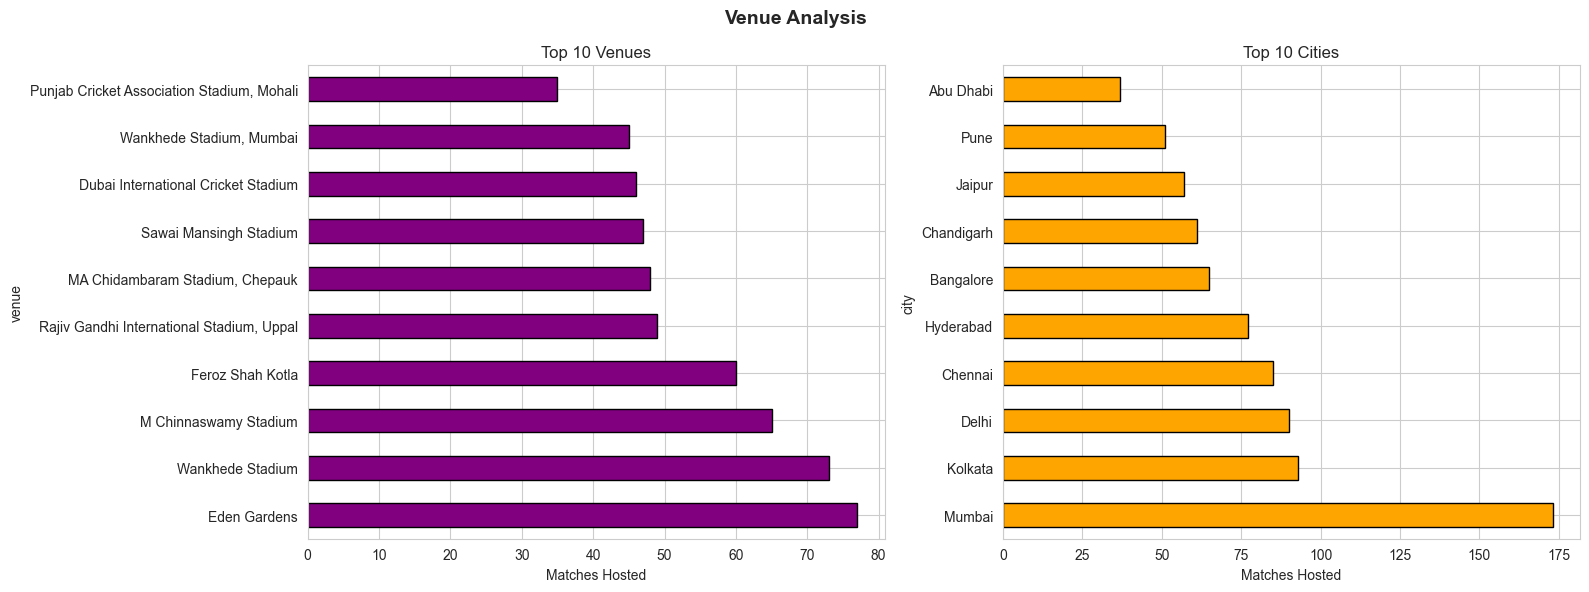

venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Wankhede Stadium, Mumbai                      45
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64
city
Mumbai        173
Kolkata        93
Delhi          90
Chennai        85
Hyderabad      77
Bangalore      65
Chandigarh     61
Jaipur         57
Pune           51
Unknown        51
Name: count, dtype: int64
<StringArray>
[     'Bangalore',     'Chandigarh',          'Delhi',         'Mumbai',
        'Kolkata',         'Jaipur',      'Hyderabad',        'Chennai',
      'Cape Town', 'Port Elizabeth',         'Durban',      'Centurion',
    'East London',   'Johannesburg

In [69]:


print("============"*50)
# Side by side — venue AND city
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Venue Analysis', 
             fontsize=14, fontweight='bold')

# Top 10 venues
df1['venue'].value_counts().head(10).plot(
    kind='barh',
    ax=axes[0],
    color='purple',
    edgecolor='black'
)
axes[0].set_title('Top 10 Venues')
axes[0].set_xlabel('Matches Hosted')
city_clean = df1[df1['city'] != 'Unknown']

# Top 10 cities
city_clean['city'].value_counts().head(10).plot(
    kind='barh',
    ax=axes[1],
    color='orange',
    edgecolor='black'
)
axes[1].set_title('Top 10 Cities')
axes[1].set_xlabel('Matches Hosted')

plt.tight_layout()
plt.show()
print("============"*50)
print(df1['venue'].value_counts().head(10))
print("============"*50)
print(df1['city'].value_counts().head(10))
print("============"*50)

print(df1['city'].unique())


### 📊 Analysis 4 Findings: Venue Analysis

**Top Venue:** Eden Gardens, Kolkata (77 matches)

**Top City:** Mumbai (173 matches) 🏆
- Mumbai has MULTIPLE venues explaining high count
- Wankhede Stadium appears with 2 different names
  → Data quality issue found!

**City Rankings:**
1. Mumbai - 173
2. Kolkata - 93
3. Delhi - 90
4. Chennai - 85

**Insight:**
> Mumbai dominates IPL hosting — financial capital
> advantage! Mumbai Indians benefit from home crowd!

# Analysis 5 — Season Trends!
QUESTION: How many matches were played per season?

HINTS:
→ df1['season'].value_counts().sort_index()
→ sort_index() sorts by year not count!
→ Line chart shows trend over time!
→ plt.plot() or kind='line'

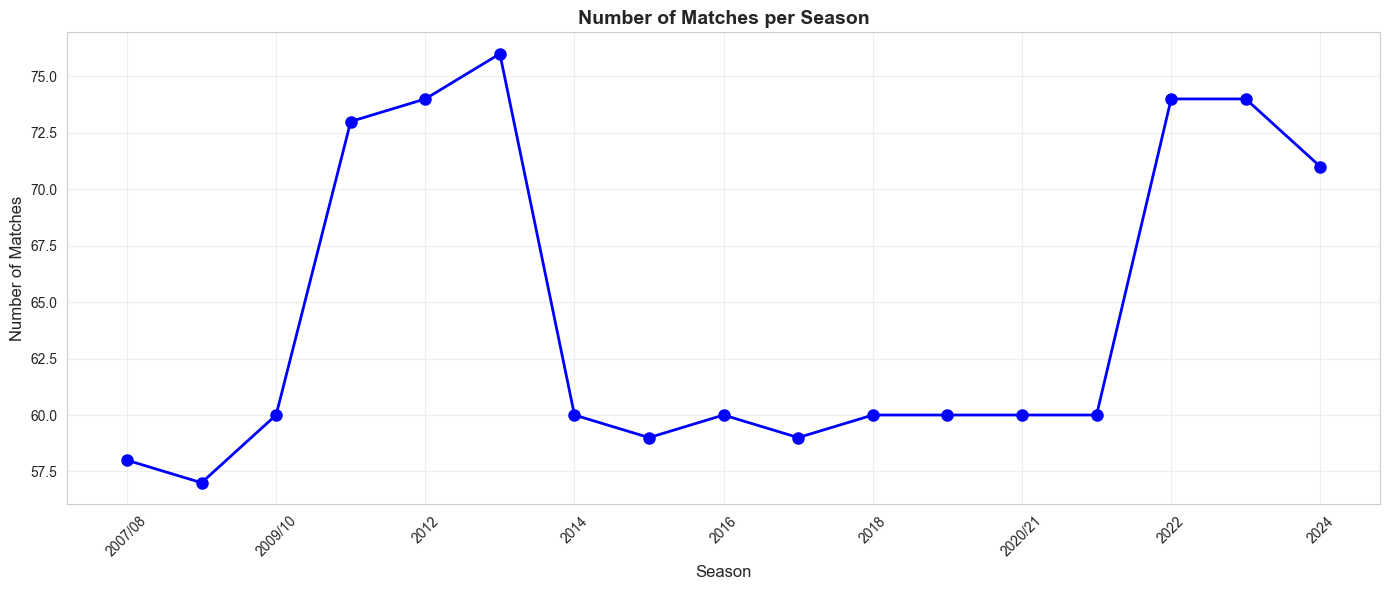

Matches per season:
season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
Name: count, dtype: int64
Least matches in a season: 57
Most matches in a season: 76


In [ ]:
plt.figure(figsize=(14, 6))

df1['season'].value_counts()\
             .sort_index()\
             .plot(kind='line',
                   marker='o',
                   color='blue',
                   linewidth=2,
                   markersize=8)

plt.title('Number of Matches per Season',
          fontsize=14, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Number of Matches', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Matches per season:")
print(df1['season'].value_counts().sort_index())

print("============"*50) 
print("Least matches in a season:"
      , df1['season'].value_counts().min() )
print("Most matches in a season:"
      , df1['season'].value_counts().max() )

## Analysis 5: Season Trends

### ❓ Question: How has IPL grown across seasons?

### 🧠 Approach:
- Count number of matches per season
- Plot a line chart to show overall trend
- Identify unusual seasons (spikes or dips)
- Investigate reasons behind anomalies

### 📌 Key Insight:
Some seasons show unexpected dips or spikes in number of matches. These are not random — they are often linked to external factors like:
- Tournament relocation (e.g., 2009, 2014)
- Global events (e.g., COVID-19 in 2020)
- Format changes (e.g., new teams in 2022)

No of matches per season:
season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
Name: count, dtype: int64


<Axes: title={'center': 'Matches per Season'}, xlabel='season'>

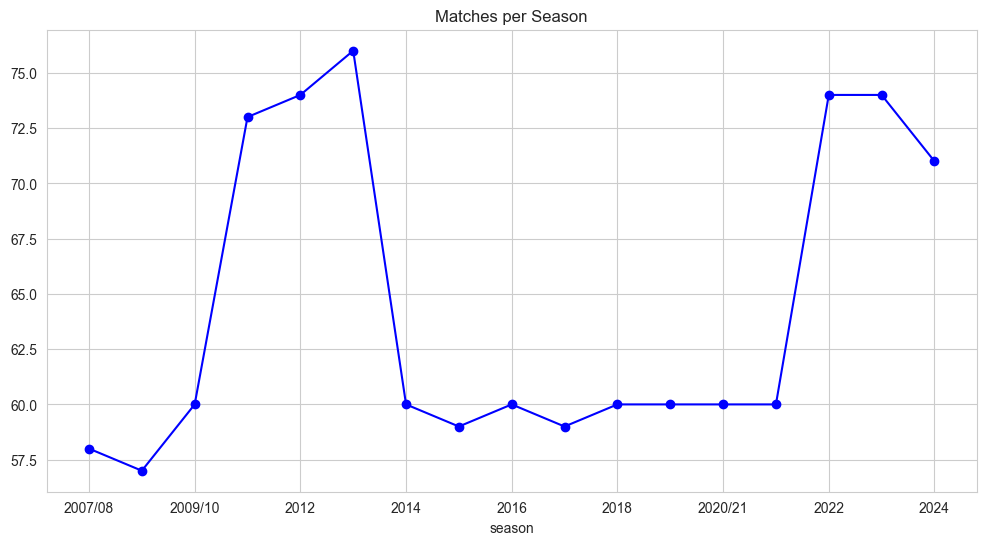

In [97]:
print("============"*50)
print("No of matches per season:")
print(df1['season'].value_counts().sort_index() )
df1['season'].value_counts().sort_index().plot(kind='line', title='Matches per Season', marker='o', color='blue')

## 📊 Analysis 5 Findings: Season Trends

### Results:
- **Most matches:** 2013 (76 matches)
- **Least matches:** 2009 (57 matches)

### 📉 Key Dips Explained:
| Season | Matches | Reason |
|--------|---------|--------|
| 2009 | 57 | IPL moved to SOUTH AFRICA (India elections!) |
| 2014 | ~60 | Partial tournament in UAE |
| 2020 | ~60 | COVID-19 → held in UAE bubble |

### 📈 Growth Trend:
- 2008-2009 → Small (new tournament!)
- 2010-2013 → Massive growth phase
- 2013-2022 → Stable (~60-76 matches)
- 2022-2024 → Slight decrease

### 🧠 Key Insight:
> IPL grew from 58 matches (2008) to 76 (2013)
> External factors caused dips in specific years
> Tournament has been remarkably consistent overall!

# Analysis 6 — Player Awards!

- QUESTION: Who won most Player of Match awards?

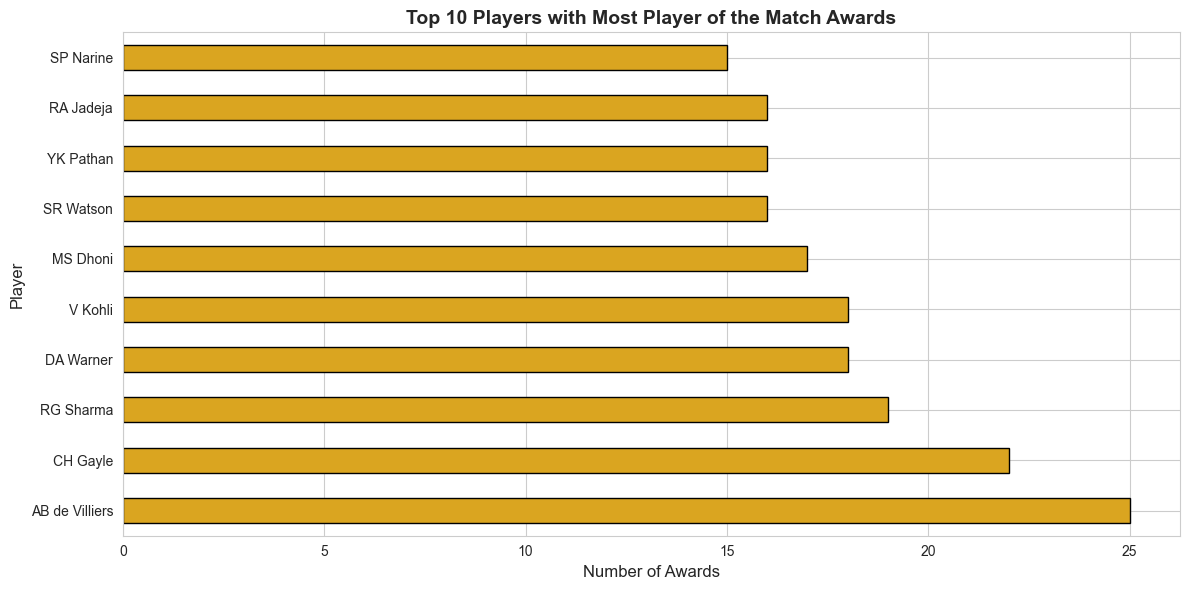

Top 10 Players with Most Player of the Match Awards:
player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
DA Warner         18
V Kohli           18
MS Dhoni          17
SR Watson         16
YK Pathan         16
RA Jadeja         16
SP Narine         15
Name: count, dtype: int64


In [108]:
players = df1[df1['player_of_match'] != 'Unknown']

players['player_of_match'].value_counts().head(10).plot(kind='barh', color='goldenrod', edgecolor='black')
plt.title('Top 10 Players with Most Player of the Match Awards', fontsize=14, fontweight='bold')
plt.xlabel('Number of Awards', fontsize=12) 
plt.ylabel('Player', fontsize=12)
plt.tight_layout()
plt.show()

print("Top 10 Players with Most Player of the Match Awards:")
print(players['player_of_match'].value_counts().head(10))

## 📊 Analysis 6 Findings: Player Awards

### 🏆 Top Player of Match Winners:

| Rank | Player | Awards | Country |
|------|--------|--------|---------|
| 1 | AB de Villiers | 25 | South Africa |
| 2 | CH Gayle | 22 | West Indies |
| 3 | RG Sharma | 19 | India |
| 4 | DA Warner | 18 | Australia |
| 5 | V Kohli | 18 | India |

### 🧠 Key Insights:
1. **AB de Villiers dominates** with 25 awards
2. **Foreign players** hold top 2 positions
   → IPL attracts world's best talent!
3. **Indian legends** — Rohit, Kohli, Dhoni all top 6
4. **All-rounders** (Jadeja, Narine, Watson) 
   win awards with both bat AND ball!

### Interesting Note:
> Top 10 players represent 5 different countries
> Shows IPL is truly a GLOBAL tournament!

# Analysis 7 — Chase Analysis!

APPROACH:
→ Find matches where team BATTED SECOND
→ Check if they won
→ Calculate chase win % per team

HINT:
When team bats second and wins:
→ result column shows 'runs' when
   team batting first wins
→ result column shows 'wickets' when
   team batting second (chasing) wins!

In [ ]:
# Teams that won CHASING (batting second)
chase_wins = df1[df1['result'] == 'wickets']

# Teams that won DEFENDING (batting first)
defend_wins = df1[df1['result'] == 'runs']

print("Teams that won CHASING (batting second):")
print(chase_wins['winner'].value_counts())
print("============"*50)
print("Teams that won DEFENDING (batting first):")
print(defend_wins['winner'].value_counts()) 

print("============"*50)
print(f"Chasing percentage: winning by batting second: ")
print(f"{(chase_wins.shape[0]/df1.shape[0]*100):.1f}%")

Teams that won CHASING (batting second):
winner
Kolkata Knight Riders          76
Mumbai Indians                 71
Rajasthan Royals               67
Chennai Super Kings            67
Royal Challengers Bangalore    61
Kings XI Punjab                45
Sunrisers Hyderabad            43
Delhi Daredevils               42
Delhi Capitals                 24
Gujarat Titans                 17
Punjab Kings                   13
Gujarat Lions                  12
Deccan Chargers                11
Lucknow Super Giants            8
Pune Warriors                   6
Rising Pune Supergiant          5
Kochi Tuskers Kerala            4
Rising Pune Supergiants         3
Royal Challengers Bengaluru     3
Name: count, dtype: int64
Teams that won DEFENDING (batting first):
winner
Chennai Super Kings            71
Mumbai Indians                 71
Kolkata Knight Riders          54
Royal Challengers Bangalore    53
Sunrisers Hyderabad            44
Rajasthan Royals               43
Kings XI Punjab            

## 📊 Analysis 7 Findings: Chase Analysis

### Results:
- Matches won by CHASING: **52.8%**
- Matches won by DEFENDING: **47.2%**

### Best Chasing Teams:
| Rank | Team | Chase Wins |
|------|------|------------|
| 1 | KKR | 76 |
| 2 | Mumbai Indians | 71 |
| 3 | Rajasthan Royals | 67 |
| 4 | CSK | 67 |

### 🧠 Combined Story (Analysis 2+3+7):
> 1. Teams prefer FIELDING after toss (64%)
> 2. Chasing wins 52.8% of matches
> 3. Strategy is VALIDATED by data!
> 4. KKR = best chasing team historically!

### Interesting Finding:
> Chasing is slightly MORE successful than defending
> This explains why captains choose to field!
> Data science confirms cricket wisdom! 🏏

# Analysis 8 — Top Run Scorers:

Top 10 Batsmen by Total Runs:
batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


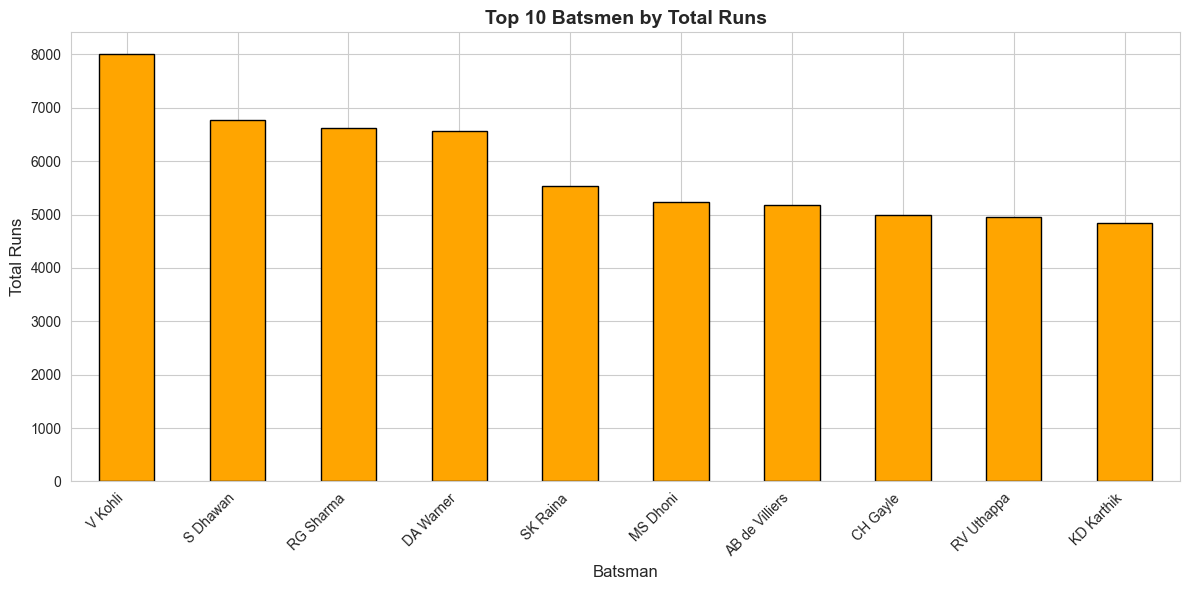

In [135]:
# print(df2.to_string(index=False))
top_batsman=df2.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)
print("Top 10 Batsmen by Total Runs:")
print(top_batsman)

plt.figure(figsize=(12, 6))
top_batsman.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Top 10 Batsmen by Total Runs', fontsize=14, fontweight='bold')
plt.xlabel('Batsman', fontsize=12)
plt.ylabel('Total Runs', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

 # Analysis Top Wicket Takers:

Top 10 Bowlers by Total Wickets:
bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
Name: is_wicket, dtype: int64


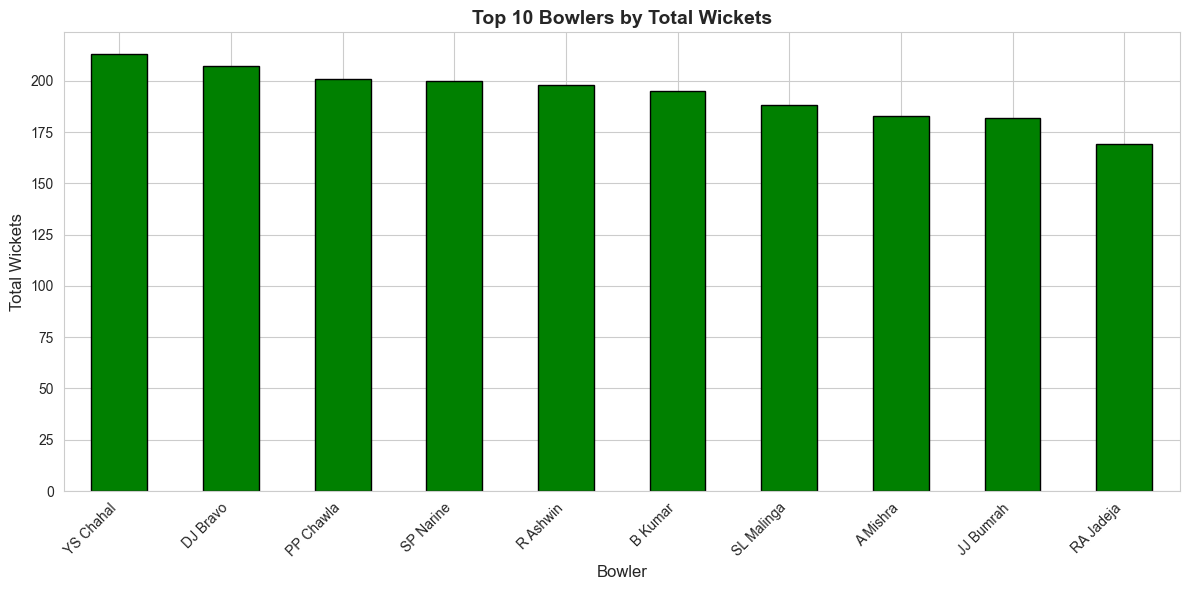

In [ ]:
# print(df2.to_string(index=False))
top_wicket_taker=df2.groupby('bowler')['is_wicket'].sum().sort_values(ascending=False).head(10)
print("Top 10 Bowlers by Total Wickets:")
print(top_wicket_taker)
plt.figure(figsize=(12, 6))
top_wicket_taker.plot(kind='bar', color='green', edgecolor='black')
plt.title('Top 10 Bowlers by Total Wickets', fontsize=14, fontweight='bold')
plt.xlabel('Bowler', fontsize=12)
plt.ylabel('Total Wickets', fontsize=12)
plt.xticks(rot ation=45, ha='right')
plt.tight_layout()
plt.show()

# Analysis 10 — Most Sixes:

Top 10 Six Hitters:
batter
CH Gayle          359
RG Sharma         281
V Kohli           273
AB de Villiers    253
MS Dhoni          252
DA Warner         236
KA Pollard        224
AD Russell        209
SV Samson         206
SK Raina          204
Name: batsman_runs, dtype: int64


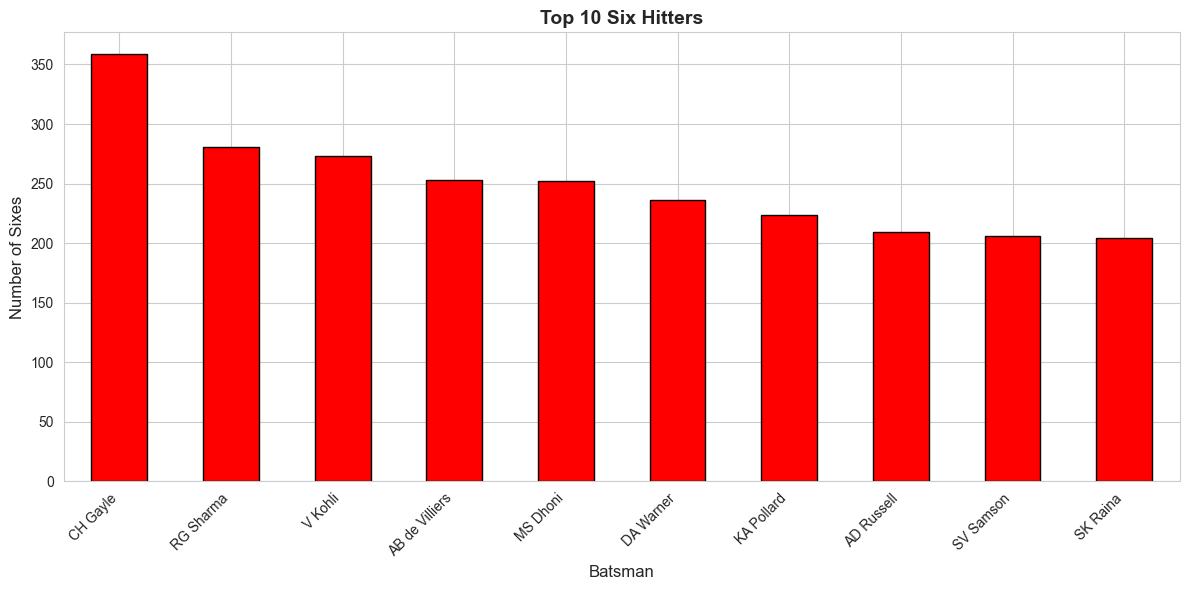

In [146]:
sixes=df2[df2['batsman_runs']==6]
top_six_hitters=sixes.groupby('batter')['batsman_runs'].count().sort_values(ascending=False).head(10)
print("Top 10 Six Hitters:")
print(top_six_hitters)
plt.figure(figsize=(12, 6))
top_six_hitters.plot(kind='bar', color='red', edgecolor='black')

plt.title('Top 10 Six Hitters', fontsize=14, fontweight='bold')
plt.xlabel('Batsman', fontsize=12)  
plt.ylabel('Number of Sixes', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Analysis 11 — Team Total Runs Per Season

Merged shape: (260920, 17)
Columns: ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'id', 'season']
    season  total_runs  match_id
0  2007/08           1    335982
1  2007/08           0    335982
2  2007/08           1    335982
3  2007/08           0    335982
4  2007/08           0    335982
Total runs per season:
season
2007/08    17937
2009       16353
2009/10    18883
2011       21154
2012       22453
2013       22602
2014       18931
2015       18353
2016       18862
2017       18786
2018       19901
2019       19434
2020/21    19416
2021       18637
2022       24395
2023       25688
2024       25971
Name: total_runs, dtype: int64

Average runs per match per season:
season
2007/08    309.0
2009       287.0
2009/10    315.0
2011       290.0
2012       303.0
2013       297.0
2014       316.0
2015       311.0
2016       314.0
201

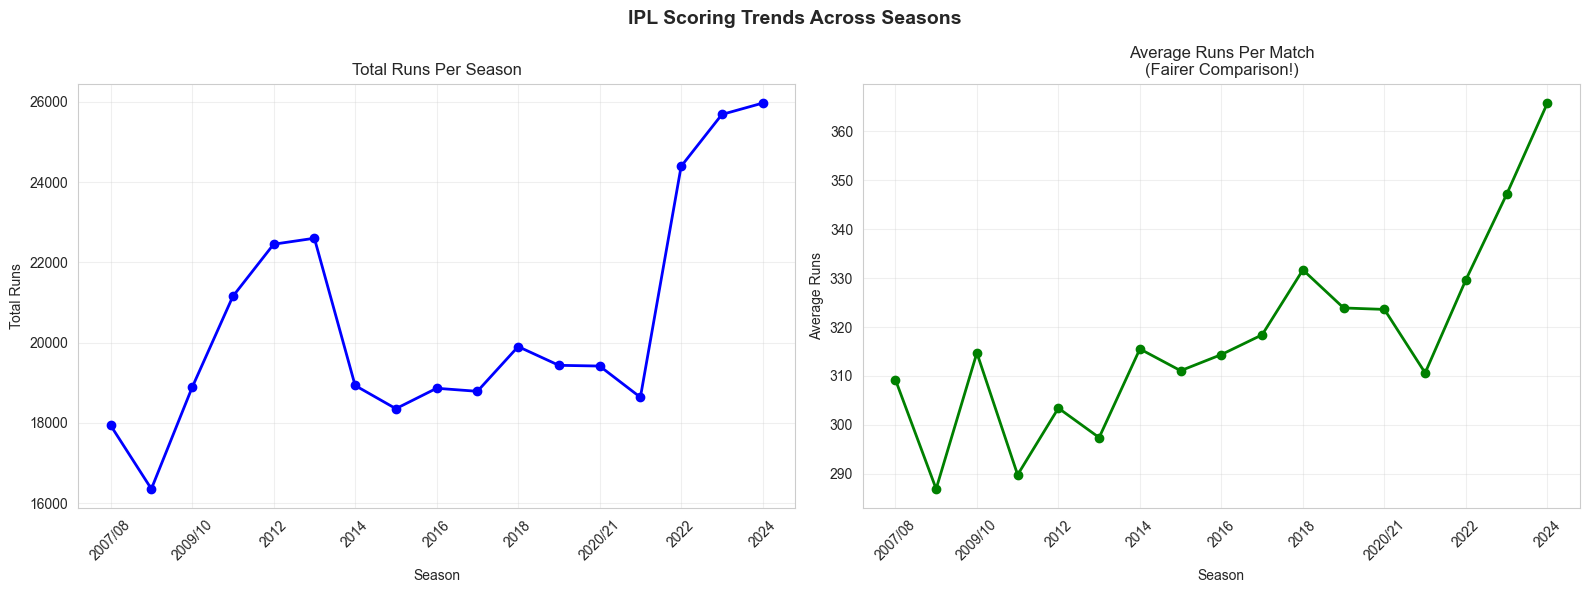

In [152]:
# STEP 1: Merge deliveries with matches
df_merged = df2.merge(
    df1[['id', 'season']],
    left_on='match_id',
    right_on='id',
    how='left'
)

print(f"Merged shape: {df_merged.shape}")
print(f"Columns: {list(df_merged.columns)}")
print(df_merged[['season',
                  'total_runs',
                  'match_id']].head())

                  # STEP 1: Total runs per season
season_runs = df_merged.groupby('season')['total_runs']\
                       .sum()\
                       .sort_index()

print("Total runs per season:")
print(season_runs)
print()

# STEP 2: Average runs per MATCH per season
# (fairer comparison — different seasons
#  have different number of matches!)
matches_per_season = df1.groupby('season').size()

avg_runs = season_runs / matches_per_season
avg_runs = avg_runs.sort_index()

print("Average runs per match per season:")
print(avg_runs.round(0))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('IPL Scoring Trends Across Seasons',
             fontsize=14, fontweight='bold')

# Plot 1: Total runs per season
season_runs.plot(kind='line',
                 marker='o',
                 color='blue',
                 linewidth=2,
                 ax=axes[0])
axes[0].set_title('Total Runs Per Season')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Total Runs')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Plot 2: Average runs per match
avg_runs.plot(kind='line',
              marker='o',
              color='green',
              linewidth=2,
              ax=axes[1])
axes[1].set_title('Average Runs Per Match\n(Fairer Comparison!)')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Average Runs')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 📊 Analysis 11 Findings: Season Scoring Trends

### Total Runs:
- **2024 = highest total runs** ever in IPL!
- More teams + more matches = more runs

### Average Runs Per Match:
- **Consistently increasing** over 17 seasons!
- Shows IPL becoming MORE attacking each year!

### Notable Dips:
| Season | Reason | Impact |
|--------|--------|--------|
| 2009 | Moved to South Africa | Fewer matches |
| 2020 | COVID → played in UAE | Slower pitches |
| 2021 | Split venue (India+UAE) | Partial impact |

### 🧠 Key Insight:
> IPL scoring has evolved dramatically!
> Average runs per match in 2008 vs 2024
> shows how T20 batting has revolutionized!
> Impact Player rule (2023) boosted scores!